In [1]:
from tqdm import tqdm
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th

import gymnasium as gym
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import importlib
if "gym_anytrading" in sys.modules:
    del sys.modules["gym_anytrading"]
    del sys.modules["gym_anytrading.envs"]

import gym_anytrading

from stable_baselines3 import PPO, DQN
from stable_baselines3.common.callbacks import BaseCallback

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
env_name = "forex-v0"

# Forex usually needs these params (safe choice)
env = gym.make(env_name, frame_bound=(10, 300), window_size=10)

In [3]:
def print_stats(reward_over_episodes):
    avg = np.mean(reward_over_episodes)
    min_val = np.min(reward_over_episodes)
    max_val = np.max(reward_over_episodes)

    print(f"Average Reward: {avg}")
    print(f"Minimum Reward: {min_val}")
    print(f"Maximum Reward: {max_val}")

    return min_val, avg, max_val


class ProgressBarCallback(BaseCallback):
    def __init__(self, check_freq: int, verbose: int = 1):
        super().__init__(verbose)
        self.check_freq = check_freq

    def _on_training_start(self) -> None:
        self.progress_bar = tqdm(total=self.model._total_timesteps, desc="model.learn()")

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            self.progress_bar.update(self.check_freq)
        return True

    def _on_training_end(self) -> None:
        self.progress_bar.close()

In [4]:
def train_test_model(model, env, seed, total_num_episodes, total_learning_timesteps=10_000):

    print("-" * 80)

    obs, info = env.reset(seed=seed)

    th.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    vec_env = None

    if model is not None:
        print(f'Model {type(model)}')
        print(f"Policy: {type(model.policy)}")

        model.learn(
            total_timesteps=total_learning_timesteps,
            callback=ProgressBarCallback(check_freq=100)
        )

        vec_env = model.get_env()
        obs = vec_env.reset()
    else:
        print("Random Actions")

    reward_over_episodes = []
    tbar = tqdm(range(total_num_episodes))

    for episode in tbar:

        if vec_env:
            obs = vec_env.reset()
        else:
            obs, info = env.reset()

        total_reward = 0
        done = False

        while not done:
            if model is not None:
                action, _ = model.predict(obs)

                try:
                    obs, reward, done, info = vec_env.step(action)
                    reward = float(reward[0])
                    done = bool(done[0])
                except IndexError:
                    obs = vec_env.reset()
                    reward, done = 0.0, True
            else:
                action = env.action_space.sample()
                try:
                    obs, reward, terminated, truncated, info = env.step(action)
                    done = terminated or truncated
                except IndexError:
                    obs, _ = env.reset()
                    reward, done = 0.0, True

            total_reward += reward

            if done:
                break

        reward_over_episodes.append(total_reward)

        if episode % 10 == 0:
            avg_reward = np.mean(reward_over_episodes)
            tbar.set_description(f'Episode: {episode}, Avg. Reward: {avg_reward:.3f}')
            tbar.update()

    tbar.close()

    return reward_over_episodes


In [5]:
seed = 42
total_num_episodes = 100

print("env_name:", env_name)
print("seed:", seed)

plot_settings = {}
plot_data = {'x': [i for i in range(1, total_num_episodes + 1)]}

env_name: forex-v0
seed: 42


In [6]:
model = None
total_learning_timesteps = 0

rewards = train_test_model(model, env, seed, total_num_episodes, total_learning_timesteps)
min_val, avg, max_val = print_stats(rewards)

label = f"Avg. {avg:>7.2f} : Random actions"
plot_data['rnd_rewards'] = rewards
plot_settings['rnd_rewards'] = {'label': label}

--------------------------------------------------------------------------------
Random Actions


Episode: 90, Avg. Reward: 16.174: 100%|██████████| 100/100 [00:00<00:00, 269.06it/s]

Average Reward: 20.329452514648438
Minimum Reward: -607.51806640625
Maximum Reward: 583.8883666992188


In [7]:
learning_timesteps_list_in_K = [25]
model_class_list = [PPO, DQN]

for timesteps in learning_timesteps_list_in_K:
    total_learning_timesteps = timesteps * 1000
    step_key = f'{timesteps}K'

    for model_class in model_class_list:

        policy_dict = model_class.policy_aliases
        policy = policy_dict.get('MlpPolicy') or policy_dict.get('MlpLstmPolicy')

        try:
            model = model_class(policy, env, verbose=0)

            class_name = type(model).__qualname__
            plot_key = f'{class_name}_rewards_' + step_key

            rewards = train_test_model(
                model, env, seed,
                total_num_episodes,
                total_learning_timesteps
            )

            min_val, avg, max_val = print_stats(rewards)

            label = f'Avg. {avg:>7.2f} : {class_name} - {step_key}'
            plot_data[plot_key] = rewards
            plot_settings[plot_key] = {'label': label}
            if 'trained_agents' not in globals():
                trained_agents = {}
            trained_agents[class_name] = model

        except Exception as e:
            print(f"ERROR: {str(e)}")
            continue

c:\Users\Admin\anaconda3\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


--------------------------------------------------------------------------------
Model <class 'stable_baselines3.ppo.ppo.PPO'>
Policy: <class 'stable_baselines3.common.policies.ActorCriticPolicy'>


model.learn(): 26600it [01:59, 222.98it/s]                           
Episode: 90, Avg. Reward: 166.557: 100%|██████████| 100/100 [00:58<00:00,  1.72it/s]


Average Reward: 168.8817500114441
Minimum Reward: -295.2992858886719
Maximum Reward: 467.09655570983887
--------------------------------------------------------------------------------
Model <class 'stable_baselines3.dqn.dqn.DQN'>
Policy: <class 'stable_baselines3.dqn.policies.DQNPolicy'>


Episode: 90, Avg. Reward: -173.955: 100%|██████████| 100/100 [00:38<00:00,  2.58it/s]

Average Reward: -174.72760726928712
Minimum Reward: -362.5023441314697
Maximum Reward: 88.90508842468262


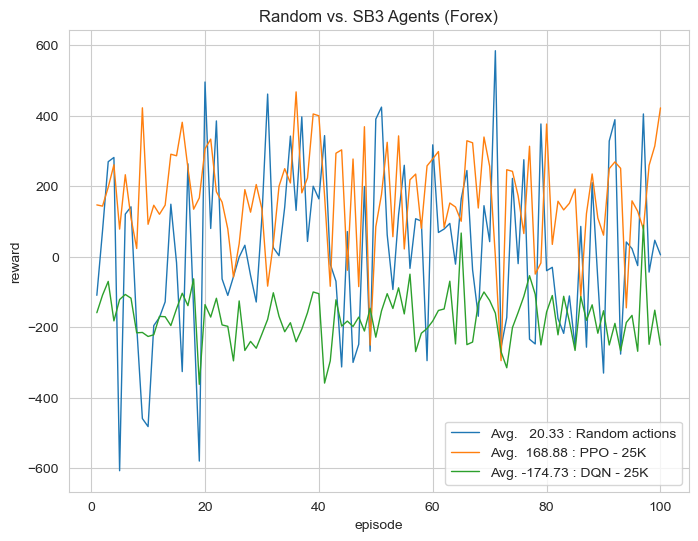

In [8]:
data = pd.DataFrame(plot_data)

sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))

for key in plot_data:
    if key == 'x':
        continue
    label = plot_settings[key]['label']
    plt.plot('x', key, data=data, linewidth=1, label=label)

plt.xlabel('episode')
plt.ylabel('reward')
plt.title('Random vs. SB3 Agents (Forex)')
plt.legend()
plt.show()

In [9]:
import plotly.graph_objects as go

env_evaluate = gym.make(env_name, frame_bound=(10, 300), window_size=10)

obs, info = env_evaluate.reset(seed=42)
done = False

tick_history = []
price_history = []
action_history = []

while not done:
    action, _ = model.predict(obs)

    tick = env_evaluate.unwrapped._current_tick
    price = env_evaluate.unwrapped.prices[tick]

    obs, reward, terminated, truncated, info = env_evaluate.step(action)
    done = terminated or truncated

    tick_history.append(tick)
    price_history.append(price)
    action_history.append(int(action))


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=tick_history,
    y=price_history,
    mode='lines',
    name='Forex Price',
    line=dict(color='gray')
))

buy_ticks, buy_prices = [], []
sell_ticks, sell_prices = [], []

prev_action = action_history[0]

for i in range(1, len(action_history)):
    if action_history[i] == 1 and prev_action == 0:
        buy_ticks.append(tick_history[i])
        buy_prices.append(price_history[i])
    elif action_history[i] == 0 and prev_action == 1:
        sell_ticks.append(tick_history[i])
        sell_prices.append(price_history[i])
    prev_action = action_history[i]

fig.add_trace(go.Scatter(
    x=buy_ticks,
    y=buy_prices,
    mode='markers',
    name='Buy',
    marker=dict(color='lime', size=12, symbol='triangle-up')
))

fig.add_trace(go.Scatter(
    x=sell_ticks,
    y=sell_prices,
    mode='markers',
    name='Sell',
    marker=dict(color='red', size=12, symbol='triangle-down')
))

fig.update_layout(
    title='Forex Trading Strategy',
    xaxis_title='Time Step',
    yaxis_title='Price',
    xaxis=dict(rangeslider=dict(visible=True)),
    template='plotly_dark'
)

fig.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_40804\2312145229.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




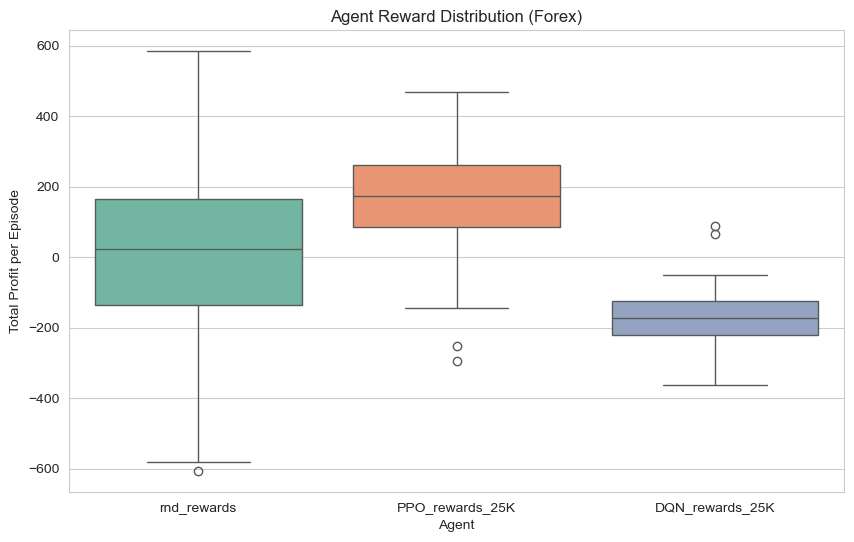

In [10]:
df_melted = data.drop(columns=['x']).melt(
    var_name='Agent',
    value_name='Total Reward'
)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Agent', y='Total Reward', data=df_melted, palette="Set2")
plt.title("Agent Reward Distribution (Forex)")
plt.ylabel("Total Profit per Episode")
plt.show()


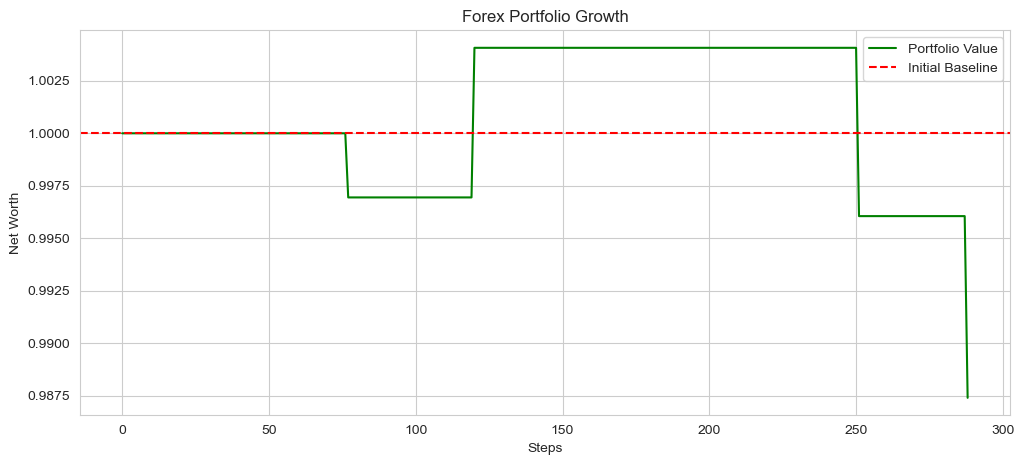

In [11]:
profit_history = env_evaluate.unwrapped.history['total_profit']

plt.figure(figsize=(12, 5))
plt.plot(profit_history, label='Portfolio Value', color='green')
plt.axhline(1.0, color='red', linestyle='--', label='Initial Baseline')

plt.title("Forex Portfolio Growth")
plt.ylabel("Net Worth")
plt.xlabel("Steps")
plt.legend()
plt.show()

In [12]:
model.save("trained_PPO_forex_agent")